# STUDY ON EFFECT OF UPFLOW AND DOWNFLOW FORCED AERATION ON COMPOSTING IN A CLOSED SYSTEM USING A PYTHON BASED SIMULATION MODEL

**Data source: Bari, Q. H., & Koenig, A. (2012). Application of a simplified mathematical model to estimate the effect of forced aeration on composting in a closed system. Waste Management, 32(11), 2037–2045. https://doi.org/10.1016/j.wasman.2012.01.014**

**_Set up and Parameters_**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
# --- Compost & Environmental Parameters ---
mass = 750          # Total initial compost mass (kg)
Ta_am = 25           # Ambient temperature (°C)
Ta_L1 = 25           # Initial layer temperature (°C)
RH = 0.75            # Relative humidity (fraction)
WC_p = 58.9          # Initial moisture content (%)
FS_p = 4             # Fixed solids fraction (%)
NVS_p = 48           # Non-volatile solids fraction (%)
VS_p = 48            # Volatile solids fraction (%)
flow_rate = 5        # Airflow rate (m³/h)

# --- Model Constants (from the kinetic model equations) ---
k = 0.00043
HL = 13500
KC = 0.00005

# --- Simulation Settings ---
layers = 6           # Number of compost layers
days = 28            # Simulation duration
cycle_hours = 6       # Hours before airflow direction switches

total_hours = days * 24
print(f"Simulation will run for {total_hours} hours across {layers} layers.")

Simulation will run for 672 hours across 6 layers.


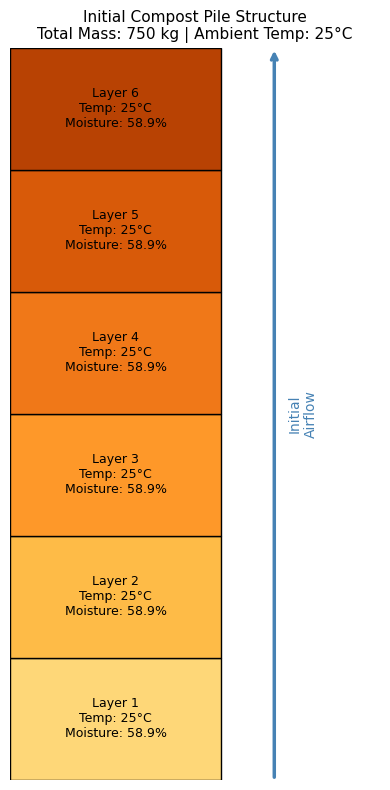

In [3]:
# Plotting Compost pile structure 
fig, ax = plt.subplots(figsize=(4, 8))

layer_height = 1
colors = plt.cm.YlOrBr(np.linspace(0.3, 0.8, layers))
pile_width = 0.6  # narrower pile, not full figure width

for i in range(layers):
    y_bottom = i * layer_height
    ax.barh(y_bottom, width=pile_width, height=layer_height, 
             align='edge', color=colors[i], edgecolor='black')
    
    y_center = y_bottom + layer_height / 2
    ax.text(pile_width / 2, y_center, 
             f'Layer {i+1}\nTemp: {Ta_L1}°C\nMoisture: {WC_p}%', 
             ha='center', va='center', fontsize=9)

# Arrow showing initial airflow, centered next to the pile
arrow_x = pile_width + 0.15
ax.annotate('', xy=(arrow_x, layers*layer_height), xytext=(arrow_x, 0),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
ax.text(arrow_x + 0.08, layers*layer_height/2, 'Initial\nAirflow', 
         color='steelblue', fontsize=10, rotation=90, va='center', ha='center')

ax.set_xlim(0, arrow_x + 0.3)
ax.set_ylim(0, layers * layer_height)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(f'Initial Compost Pile Structure\nTotal Mass: {mass} kg | Ambient Temp: {Ta_am}°C', fontsize=11)
plt.tight_layout()
plt.show()

**_Initialize Arrays_**

In [4]:
def create_2d_array(rows, cols):
    """Creates a 2D grid filled with zeros, sized layers x hours."""
    return [[0.0 for _ in range(cols)] for _ in range(rows)]

# Airflow into/out of each layer, each hour
mai = create_2d_array(layers, total_hours)   # mass of air IN
mao = create_2d_array(layers, total_hours)   # mass of air OUT

# Compost composition tracking
VS = create_2d_array(layers, total_hours)     # Volatile Solids remaining (kg)
H2O = create_2d_array(layers, total_hours)    # Water content (kg)
mc = create_2d_array(layers, total_hours)     # Total compost mass in layer (kg)
WC = create_2d_array(layers, total_hours)     # Moisture content (%)

# Heat & moisture transfer tracking
D_H2O = create_2d_array(layers, total_hours)  # Change in water content
KL = create_2d_array(layers, total_hours)     # Specific heat of compost
D_BVS = create_2d_array(layers, total_hours)  # Decomposed volatile solids (this hour)
T_BVS = create_2d_array(layers, total_hours)  # Total decomposed VS (cumulative)

# Heat balance components
D = create_2d_array(layers, total_hours)      # Numerator of temperature equation
N = create_2d_array(layers, total_hours)      # Denominator of temperature equation
Ta = create_2d_array(layers, total_hours)     # Layer temperature (°C) — your main output

# Oxygen & decomposition rate tracking
o2 = create_2d_array(layers, total_hours)     # Oxygen content (%)
kt = create_2d_array(layers, total_hours)     # Temperature-dependent decomposition rate
WCf = create_2d_array(layers, total_hours)    # Moisture correction factor

total_D_H2O = 0.0   # Running total of all water lost across the whole simulation

print(f"Created {layers} x {total_hours} arrays for {14} tracked variables.")
print(f"Each array shape: {len(Ta)} layers x {len(Ta[0])} hours")

Created 6 x 672 arrays for 14 tracked variables.
Each array shape: 6 layers x 672 hours


**_Intial hour( hour 0) setting_**

Starting Calculation for each Layer

In [5]:
# Saturation vapor content of incoming air (used throughout the simulation)
V_in = 0.622 * (RH * math.pow(10, (8.896 - (2238 / (273 + Ta_am))))) / (760 - RH * math.pow(10, (8.896 - (2238 / (273 + Ta_am)))))

# Density of ambient air
Air_d = 1.3009 - (0.0046 * Ta_am)

# Mass of compost in a single layer
L1 = mass / layers

# Break that layer's mass into its components, based on the % fractions from Section 1
I_WC = (WC_p * L1) / 100      # Initial Water Content (kg)
I_TS = L1 - I_WC              # Initial Total Solids (kg) = layer mass minus water
I_FS = (I_TS * FS_p) / 100    # Initial Fixed Solids (kg)
I_NVS_L1 = (I_TS * NVS_p) / 100  # Initial Non-Volatile Solids (kg)
I_VS = (I_TS * VS_p) / 100    # Initial Volatile Solids (kg)

print(f"Mass per layer: {L1:.2f} kg")
print(f"Initial Water: {I_WC:.2f} kg | Fixed Solids: {I_FS:.2f} kg | Non-Volatile Solids: {I_NVS_L1:.2f} kg | Volatile Solids: {I_VS:.2f} kg")

Mass per layer: 125.00 kg
Initial Water: 73.62 kg | Fixed Solids: 2.06 kg | Non-Volatile Solids: 24.66 kg | Volatile Solids: 24.66 kg


Fill in hour 0 for every layer

In [6]:
for layer in range(layers):
    
    # Airflow: layer 0 gets air directly from outside; other layers get air from the previous layer
    if layer == 0:
        mai[layer][0] = flow_rate * Air_d
    else:
        mai[layer][0] = mao[layer-1][0]
    
    mao[layer][0] = mai[layer][0]  # at hour 0, no decomposition has happened yet, so air out = air in
    
    VS[layer][0] = I_VS
    H2O[layer][0] = I_WC
    mc[layer][0] = I_FS + I_NVS_L1 + VS[layer][0] + H2O[layer][0]
    WC[layer][0] = WC_p
    
    # Nothing has decomposed yet, no heat/moisture transfer yet
    D_H2O[layer][0] = 0
    KL[layer][0] = 0
    D_BVS[layer][0] = 0
    D[layer][0] = 0
    N[layer][0] = 0
    T_BVS[layer][0] = 0
    Ta[layer][0] = Ta_L1
    
    # Oxygen: layer 0 gets fresh air (21% oxygen); other layers get whatever oxygen is left after the layer below it
    if layer == 0:
        o2_val = 100 * (mai[layer][0] * 0.21 - D_BVS[layer][0] * 1.3) / mao[layer][0] if mao[layer][0] > 0 else 0
    else:
        o2_val = 100 * (mai[layer][0] * o2[layer-1][0] / 100 - D_BVS[layer][0] * 1.3) / mao[layer][0] if mao[layer][0] > 0 else 0
    o2[layer][0] = max(o2_val, 0)
    
    # Decomposition rate depends on temperature; moisture correction factor depends on how wet the layer is
    kt[layer][0] = 0 if Ta_am > 65 else k * (math.pow(1.07, Ta_am - 25) - math.pow(1.3, Ta_am - 55))
    WCf[layer][0] = 0 if WC[layer][0] < 30 else (1 if WC[layer][0] > 45 else (WC[layer][0] - 30) / 15)

print("Hour 0 initialized for all layers.")
print(f"Layer 1 starting temp: {Ta[0][0]}°C, moisture: {WC[0][0]}%, oxygen: {o2[0][0]:.2f}%")

Hour 0 initialized for all layers.
Layer 1 starting temp: 25°C, moisture: 58.9%, oxygen: 21.00%


**_Simulation loop for two way aeration_**

Define the decomposition & airflow function

In [7]:
def calculate_airflow_decomposition(layer, hour, idx, prev_layer):
    D_BVS[layer][hour] = WCf[layer][hour-1] * kt[layer][hour-1] * VS[layer][hour-1]
    
    if idx == 0:
        mai[layer][hour] = flow_rate * Air_d
    else:
        mai[layer][hour] = mao[prev_layer][hour]
    
    mao[layer][hour] = mai[layer][hour] + 0.5 * D_BVS[layer][hour]
    VS[layer][hour] = VS[layer][hour-1] - D_BVS[layer][hour]

Define the moisture balance function

In [8]:
def calculate_moisture(layer, hour, idx, prev_layer):
    if idx == 0:
        H2O_O = 0.622 * math.pow(10, (8.896 - (2238 / (273 + Ta[layer][hour-1])))) / (760 - math.pow(10, (8.896 - (2238 / (273 + Ta[layer][hour-1])))))
        D_H2O[layer][hour] = (H2O_O * mao[layer][hour]) - (V_in * mai[layer][hour])
    else:
        H2O_O = 0.622 * math.pow(10, (8.896 - (2238 / (273 + Ta[layer][hour-1])))) / (760 - math.pow(10, (8.896 - (2238 / (273 + Ta[layer][hour-1])))))
        H2O_I = 0.622 * math.pow(10, (8.896 - (2238 / (273 + Ta[prev_layer][hour-1])))) / (760 - math.pow(10, (8.896 - (2238 / (273 + Ta[prev_layer][hour-1])))))
        D_H2O[layer][hour] = (H2O_O * mao[layer][hour]) - (H2O_I * mai[layer][hour])
    
    global total_D_H2O
    total_D_H2O += D_H2O[layer][hour]
    H2O[layer][hour] = H2O[layer][hour-1] + 0.5 * D_BVS[layer][hour] - D_H2O[layer][hour]

Define the mass/moisture%/specific heat function

In [9]:
def calculate_mass_properties(layer, hour):
    mc[layer][hour] = I_FS + I_NVS_L1 + VS[layer][hour] + H2O[layer][hour]
    WC[layer][hour] = (H2O[layer][hour] * 100 / mc[layer][hour]) if mc[layer][hour] > 0 else 0
    
    if mc[layer][hour] > 0:
        KL[layer][hour] = ((I_FS * 0.8) + (I_NVS_L1 * 2.5) + (VS[layer][hour] * 2.5) + (H2O[layer][hour] * 4.2)) / mc[layer][hour]
    else:
        KL[layer][hour] = 0

Define the temperature (heat balance) function

In [10]:
def calculate_temperature(layer, hour, idx, prev_layer):
    Hmc_1 = mc[layer][hour] * KL[layer][hour] * (Ta_L1 if hour == 1 else Ta[layer][hour-1])
    Hmc_2 = mai[layer][hour] * 1.005 * (Ta_am if idx == 0 else Ta[prev_layer][hour])
    Hmc_3 = D_BVS[layer][hour] * HL
    Hmc_4 = KC * KL[layer][hour] * mc[layer][hour] * Ta_am
    Hmc_5 = D_H2O[layer][hour] * (2502.1 - 2.4 * (Ta_am if hour == 1 else Ta[layer][hour-1]))
    if idx != 0:
        Hmc_5 += (Ta[layer][hour-1] - Ta[prev_layer][hour-1]) * 1.7829 * D_H2O[prev_layer][hour]
    Hmc_6 = mc[layer][hour] * KL[layer][hour]
    Hmc_7 = mao[layer][hour] * 1.005
    Hmc_8 = KC * KL[layer][hour] * mc[layer][hour]
    
    D[layer][hour] = Hmc_1 + Hmc_2 + Hmc_3 + Hmc_4 - Hmc_5
    N[layer][hour] = Hmc_6 + Hmc_7 + Hmc_8
    Ta[layer][hour] = D[layer][hour] / N[layer][hour] if N[layer][hour] != 0 else 0

Define the oxygen & decomposition rate function

In [11]:
def calculate_oxygen_and_rates(layer, hour, idx, prev_layer):
    if idx == 0:
        o2_val = 100 * (mai[layer][hour] * 0.21 - D_BVS[layer][hour] * 1.3) / mao[layer][hour] if mao[layer][hour] > 0 else 0
    else:
        o2_val = 100 * (mai[layer][hour] * o2[prev_layer][hour] / 100 - D_BVS[layer][hour] * 1.3) / mao[layer][hour] if mao[layer][hour] > 0 else 0
    o2[layer][hour] = max(o2_val, 0)
    
    kt[layer][hour] = 0 if Ta[layer][hour] > 65 else k * (math.pow(1.07, Ta[layer][hour] - 25) - math.pow(1.3, Ta[layer][hour] - 55))
    WCf[layer][hour] = 0 if WC[layer][hour] < 30 else (1 if WC[layer][hour] > 45 else (WC[layer][hour] - 30) / 15)
    T_BVS[layer][hour] = T_BVS[layer][hour-1] + D_BVS[layer][hour]

**The actual loop (Switching Air Direction)**

In [12]:
for hour in range(1, total_hours):
    
    if (hour // cycle_hours) % 2 == 0:
        layer_order = list(range(layers))
    else:
        layer_order = list(range(layers-1, -1, -1))
    
    for idx in range(layers):
        layer = layer_order[idx]
        prev_layer = layer_order[idx-1] if idx != 0 else None
        
        calculate_airflow_decomposition(layer, hour, idx, prev_layer)
        calculate_moisture(layer, hour, idx, prev_layer)
        calculate_mass_properties(layer, hour)
        calculate_temperature(layer, hour, idx, prev_layer)
        calculate_oxygen_and_rates(layer, hour, idx, prev_layer)

print("Simulation complete!")
print(f"Final temperature, Layer 1: {Ta[0][total_hours-1]:.2f}°C")
print(f"Final temperature, Layer 6: {Ta[5][total_hours-1]:.2f}°C")

Simulation complete!
Final temperature, Layer 1: 38.43°C
Final temperature, Layer 6: 28.72°C


**_Mass Balance Summary_**

Total decomposed volatile solids, summed across all layers

In [13]:
total_decomposed_bvs_all_layers = 0
final_hour_index = total_hours - 1

for layer in range(layers):
    total_decomposed_bvs_all_layers += T_BVS[layer][final_hour_index]

print(f"Total Volatile Solids decomposed across all layers: {total_decomposed_bvs_all_layers:.2f} kg")

Total Volatile Solids decomposed across all layers: 79.75 kg


Initial mass breakdown (whole pile, not just one layer)

In [14]:
M_Water = mass * WC_p * 0.01
M_TS = mass - M_Water
M_FS = M_TS * FS_p * 0.01
M_NVS = M_TS * NVS_p * 0.01
M_VS = M_TS * VS_p * 0.01

print(f"Initial — Water: {M_Water:.2f} kg | Fixed Solids: {M_FS:.2f} kg | Non-Volatile Solids: {M_NVS:.2f} kg | Volatile Solids: {M_VS:.2f} kg")

Initial — Water: 441.75 kg | Fixed Solids: 12.33 kg | Non-Volatile Solids: 147.96 kg | Volatile Solids: 147.96 kg


Final mass breakdown

In [15]:
F_VS = M_VS - total_decomposed_bvs_all_layers
F_Water = M_Water - total_D_H2O
F_FS = M_FS
F_NVS = M_NVS

F_TS = F_FS + F_VS + F_NVS
F_mass = F_Water + F_TS

print(f"Final — Water: {F_Water:.2f} kg | Fixed Solids: {F_FS:.2f} kg | Non-Volatile Solids: {F_NVS:.2f} kg | Volatile Solids: {F_VS:.2f} kg")
print(f"\nInitial total mass: {mass:.2f} kg")
print(f"Final total mass: {F_mass:.2f} kg")
print(f"Mass reduction: {mass - F_mass:.2f} kg ({(mass - F_mass)/mass*100:.1f}%)")

Final — Water: 68.49 kg | Fixed Solids: 12.33 kg | Non-Volatile Solids: 147.96 kg | Volatile Solids: 68.21 kg

Initial total mass: 750.00 kg
Final total mass: 297.00 kg
Mass reduction: 453.00 kg (60.4%)


**_Visualization_**

Temperature profile

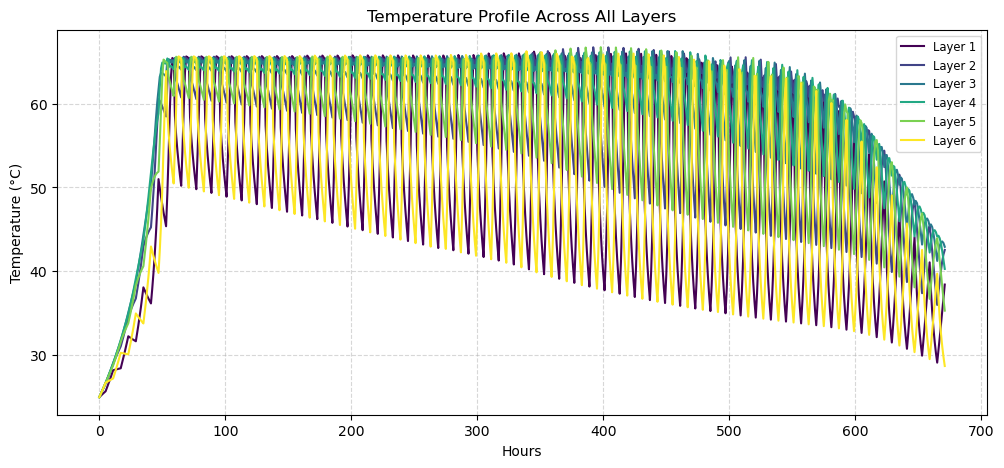

In [16]:
hours = list(range(total_hours))
colors = plt.cm.viridis(np.linspace(0, 1, layers))

plt.figure(figsize=(12, 5))
for layer in range(layers):
    plt.plot(hours, Ta[layer], label=f'Layer {layer+1}', color=colors[layer])

plt.xlabel('Hours')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Profile Across All Layers')
plt.legend(loc='best', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Moisture profile

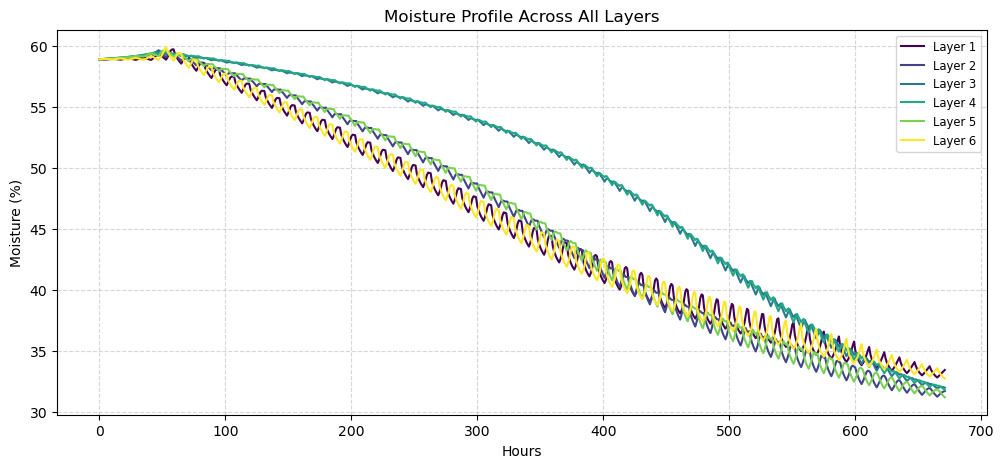

In [17]:
plt.figure(figsize=(12, 5))
for layer in range(layers):
    plt.plot(hours, WC[layer], label=f'Layer {layer+1}', color=colors[layer])

plt.xlabel('Hours')
plt.ylabel('Moisture (%)')
plt.title('Moisture Profile Across All Layers')
plt.legend(loc='best', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Oxygen profile

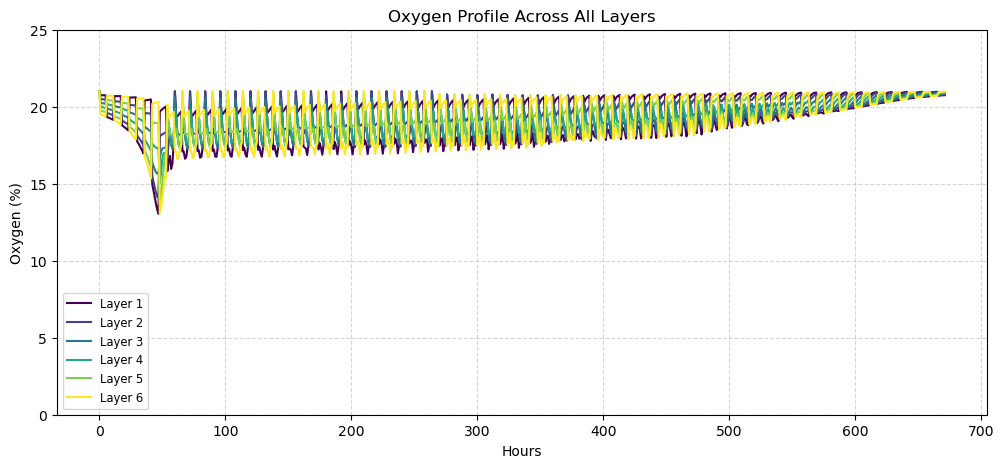

In [18]:
plt.figure(figsize=(12, 5))
for layer in range(layers):
    plt.plot(hours, o2[layer], label=f'Layer {layer+1}', color=colors[layer])

plt.xlabel('Hours')
plt.ylabel('Oxygen (%)')
plt.title('Oxygen Profile Across All Layers')
plt.legend(loc='best', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, 25)
plt.show()

Volatile solids reduction

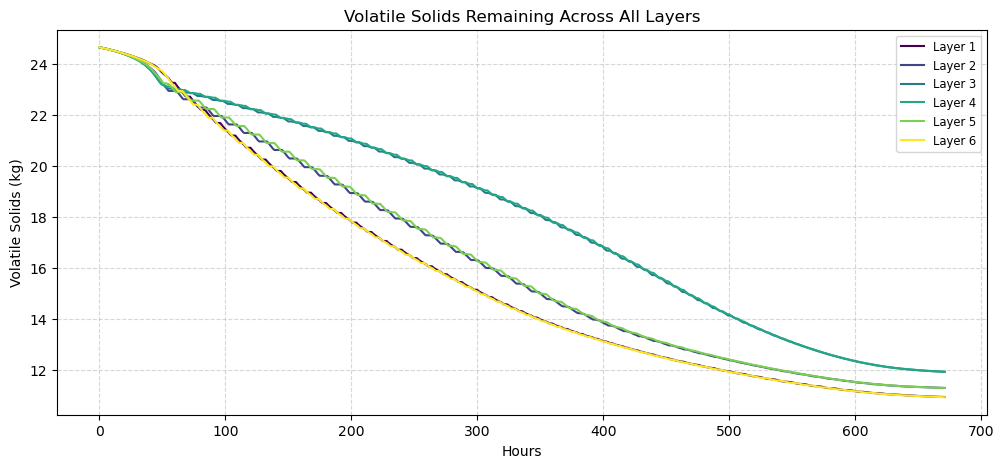

In [19]:
plt.figure(figsize=(12, 5))
for layer in range(layers):
    plt.plot(hours, VS[layer], label=f'Layer {layer+1}', color=colors[layer])

plt.xlabel('Hours')
plt.ylabel('Volatile Solids (kg)')
plt.title('Volatile Solids Remaining Across All Layers')
plt.legend(loc='best', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Initial vs Final mass composition

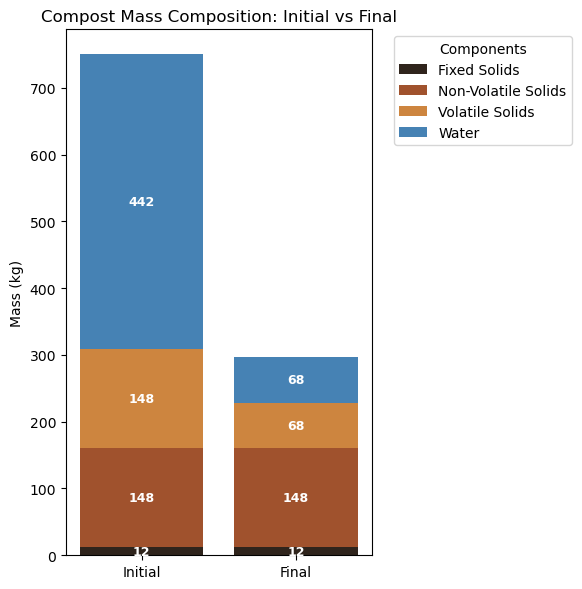

In [20]:
components = ['Fixed Solids', 'Non-Volatile Solids', 'Volatile Solids', 'Water']
initial_values = [M_FS, M_NVS, M_VS, M_Water]
final_values = [F_FS, F_NVS, F_VS, F_Water]
bar_colors = ['#2F241C', '#A0522D', '#CD853F', '#4682B4']

fig, ax = plt.subplots(figsize=(6, 6))

bottom_init = 0
bottom_final = 0
for i, comp in enumerate(components):
    ax.bar('Initial', initial_values[i], bottom=bottom_init, color=bar_colors[i], label=comp)
    ax.bar('Final', final_values[i], bottom=bottom_final, color=bar_colors[i])
    
    ax.text('Initial', bottom_init + initial_values[i]/2, f'{initial_values[i]:.0f}', 
             ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    ax.text('Final', bottom_final + final_values[i]/2, f'{final_values[i]:.0f}', 
             ha='center', va='center', color='white', fontsize=9, fontweight='bold')
    
    bottom_init += initial_values[i]
    bottom_final += final_values[i]

ax.set_ylabel('Mass (kg)')
ax.set_title('Compost Mass Composition: Initial vs Final')
ax.legend(title='Components', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [21]:
**_Conclusion: 

SyntaxError: invalid syntax (2863903567.py, line 1)